# IMDB Dataset Analysis

This notebook contains the analysis of IMDB dataset using PySpark.

## Dataset Description

The IMDB (Internet Movie Database) dataset is one of the most comprehensive movie and TV show databases in the world. This analysis focuses on seven main tables from the dataset:

### 1. title.basics
This table contains basic information about titles (movies, TV shows, etc.) with the following fields:
- `tconst` (string): Unique identifier for each title
- `titleType` (string): Type of title (movie, TV series, short, etc.)
- `primaryTitle` (string): The more popular title in the original language
- `originalTitle` (string): Original title in the original language
- `isAdult` (boolean): Indicates if the title is adult content
- `startYear` (integer): Release year of the title
- `endYear` (integer): End year for TV series (NULL for movies)
- `runtimeMinutes` (integer): Runtime in minutes
- `genres` (string): Comma-separated list of genres

### 2. title.ratings
This table contains rating information for titles with the following fields:
- `tconst` (string): Unique identifier for each title (links to title.basics)
- `averageRating` (double): Average rating from 1.0 to 10.0
- `numVotes` (integer): Number of votes the title has received

### 3. title.crew
This table contains information about directors and writers for titles:
- `tconst` (string): Unique identifier for the title
- `directors` (string): Comma-separated list of director nconsts
- `writers` (string): Comma-separated list of writer nconsts

### 4. title.principals
This table contains information about principal cast/crew members for titles:
- `tconst` (string): Unique identifier for the title
- `ordering` (integer): Order of importance in the credits
- `nconst` (string): Unique identifier for the person
- `category` (string): Category of job (actor, director, etc.)
- `job` (string): Specific job title
- `characters` (string): Character name if applicable

### 5. name.basics
This table contains basic information about people in the IMDB database:
- `nconst` (string): Unique identifier for the person
- `primaryName` (string): Name by which the person is most often credited
- `birthYear` (integer): Year of birth
- `deathYear` (integer): Year of death if applicable
- `primaryProfession` (string): Comma-separated list of primary professions
- `knownForTitles` (string): Comma-separated list of titles the person is known for

### 6. title.akas
This table contains alternative titles for movies and TV shows:
- `titleId` (string): Unique identifier for the title
- `ordering` (integer): Order of the title in the list
- `title` (string): Alternative title
- `region` (string): Region where this title is used
- `language` (string): Language of the title
- `types` (string): Type of title (alternative, working title, etc.)
- `attributes` (string): Additional attributes
- `isOriginalTitle` (boolean): Whether this is the original title

### 7. title.episode
This table contains episode information for TV shows:
- `tconst` (string): Unique identifier for the episode
- `parentTconst` (string): Unique identifier for the parent TV show
- `seasonNumber` (integer): Season number
- `episodeNumber` (integer): Episode number

### Dataset Relationships
The tables are related through the following key fields:
- `tconst` links `title.basics`, `title.ratings`, `title.crew`, `title.principals`, and `title.episode`
- `nconst` links `name.basics` with `title.principals` and the director/writer lists in `title.crew`
- `titleId` in `title.akas` corresponds to `tconst` in other title-related tables
- `parentTconst` in `title.episode` links to the parent TV show's `tconst`

### Business Value
This dataset is valuable for:
1. Understanding content trends over time
2. Analyzing audience preferences through ratings
3. Identifying popular genres and content types
4. Studying the relationship between runtime and ratings
5. Comparing different types of content (movies vs TV shows)
6. Analyzing cast and crew relationships
7. Studying international title variations
8. Understanding TV show episode structures

### Data Quality Notes
- The dataset is regularly updated and maintained by IMDB
- Some older titles may have incomplete information
- Ratings are based on user submissions and may be biased
- The dataset includes both current and historical content

In [166]:
from pyspark.sql import SparkSession
from pyspark.sql.window import Window
from pyspark.sql.types import *
from pyspark.sql.functions import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [101]:
spark = SparkSession.builder \
    .appName("Danylo_IMDB_Analysis") \
    .master("local[*]") \
    .config("spark.driver.host", "192.168.0.59") \
    .config("spark.driver.bindAddress", "192.168.0.59") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "10") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

In [102]:
spark.sparkContext.setLogLevel("ERROR")

## Data Loading and Schema Definition

Let's define the schema for IMDB datasets and load them.

In [103]:
title_basics_schema = StructType([
    StructField("tconst", StringType(), False),
    StructField("titleType", StringType(), False),
    StructField("primaryTitle", StringType(), False),
    StructField("originalTitle", StringType(), False),
    StructField("isAdult", IntegerType(), True),
    StructField("startYear", IntegerType(), True),
    StructField("endYear", IntegerType(), True),
    StructField("runtimeMinutes", IntegerType(), True),
    StructField("genres", StringType(), True)
])

In [104]:
title_ratings_schema = StructType([
    StructField("tconst", StringType(), False),
    StructField("averageRating", DoubleType(), False),
    StructField("numVotes", IntegerType(), False)
])

In [105]:
title_crew_schema = StructType([
    StructField("tconst", StringType(), False),
    StructField("directors", StringType(), False),
    StructField("writers", StringType(), False)
])

In [106]:
title_principals_schema = StructType([
    StructField("tconst", StringType(), False),
    StructField("ordering", IntegerType(), False),
    StructField("nconst", StringType(), False),
    StructField("category", StringType(), False),
    StructField("job", StringType(), True),
    StructField("characters", StringType(), True)
])

In [107]:
name_basics_schema = StructType([
    StructField("nconst", StringType(), False),
    StructField("primaryName", StringType(), True),
    StructField("birthYear", IntegerType(), True),
    StructField("deathYear", IntegerType(), True),
    StructField("primaryProfession", StringType(), True),
    StructField("knownForTitles", StringType(), True)
])

In [108]:
title_akas_schema = StructType([
    StructField("titleId", StringType(), False),
    StructField("ordering", IntegerType(), False),
    StructField("title", StringType(), False),
    StructField("region", StringType(), True),
    StructField("language", StringType(), True),
    StructField("types", StringType(), True),
    StructField("attributes", StringType(), True),
    StructField("isOriginalTitle", BooleanType(), True)
])

In [109]:
title_episode_schema = StructType([
    StructField("tconst", StringType(), False),
    StructField("parentTconst", StringType(), False),
    StructField("seasonNumber", IntegerType(), True),
    StructField("episodeNumber", IntegerType(), True)
])

In [110]:
data_path = "../data/imdb"

title_basics_df = spark.read.csv(
    f"{data_path}/title.basics.tsv",
    sep="\t",
    header=True,
    schema=title_basics_schema,
    nullValue="\\N"
)

title_ratings_df = spark.read.csv(
    f"{data_path}/title.ratings.tsv",
    sep="\t",
    header=True,
    schema=title_ratings_schema,
    nullValue="\\N"
)

title_crew_df = spark.read.csv(
    f"{data_path}/title.crew.tsv",
    sep="\t",
    header=True,
    schema=title_crew_schema,
    nullValue="\\N"
)

title_principals_df = spark.read.csv(
    f"{data_path}/title.principals.tsv",
    sep="\t",
    header=True,
    schema=title_principals_schema,
    nullValue="\\N"
)

name_basics_df = spark.read.csv(
    f"{data_path}/name.basics.tsv",
    sep="\t",
    header=True,
    schema=name_basics_schema,
    nullValue="\\N"
)

title_akas_df = spark.read.csv(
    f"{data_path}/title.akas.tsv",
    sep="\t",
    header=True,
    schema=title_akas_schema,
    nullValue="\\N"
)

title_episode_df = spark.read.csv(
    f"{data_path}/title.episode.tsv",
    sep="\t",
    header=True,
    schema=title_episode_schema,
    nullValue="\\N"
)

## Basic Data Analysis

In [132]:
from pyspark.sql import DataFrame
from pyspark.sql.functions import col, count, when, isnull, mean, stddev, min, max, countDistinct
from typing import Dict, Any

def validate_dataframe(df: DataFrame, table_name: str) -> Dict[str, Any]:

    total_rows = df.count()
    total_columns = len(df.columns)
    
    # Аналіз NULL значень
    null_counts = {}
    for column in df.columns:
        null_count = df.filter(col(column).isNull()).count()
        null_percentage = (null_count / total_rows) * 100 if total_rows > 0 else 0
        null_counts[column] = {
            "count": null_count,
            "percentage": null_percentage
        }
    
    # Перевірка дублікатів первинного ключа
    primary_key = df.columns[0]
    duplicate_count = df.groupBy(primary_key).count().filter("count > 1").count()
    
    
    # Статистика для числових колонок
    numeric_stats = {}
    numeric_columns = [col for col in df.columns if str(df.schema[col].dataType) in ["IntegerType", "DoubleType", "LongType"]]
    
    if numeric_columns:
        
        stats_df = df.select([
            *[count(when(col(c).isNotNull(), 1)).alias(f"{c}_non_null") for c in numeric_columns],
            *[count(when(col(c) == 0, 1)).alias(f"{c}_zero") for c in numeric_columns],
            *[count(when(col(c) < 0, 1)).alias(f"{c}_negative") for c in numeric_columns],
            *[mean(col(c)).alias(f"{c}_mean") for c in numeric_columns],
            *[stddev(col(c)).alias(f"{c}_stddev") for c in numeric_columns],
            *[min(col(c)).alias(f"{c}_min") for c in numeric_columns],
            *[max(col(c)).alias(f"{c}_max") for c in numeric_columns]
        ]).collect()[0]
        
        for column in numeric_columns:
            numeric_stats[column] = {
                "non_null_count": stats_df[f"{column}_non_null"],
                "zero_count": stats_df[f"{column}_zero"],
                "negative_count": stats_df[f"{column}_negative"],
                "mean": stats_df[f"{column}_mean"],
                "stddev": stats_df[f"{column}_stddev"],
                "min": stats_df[f"{column}_min"],
                "max": stats_df[f"{column}_max"]
            }
            
            # Обчислюємо квантилі 
            try:
                quantiles = df.approxQuantile(column, [0.25, 0.5, 0.75], 0.01)
                numeric_stats[column].update({
                    "q1": quantiles[0],
                    "median": quantiles[1],
                    "q3": quantiles[2]
                })
            except Exception as e:
                print(f"Помилка при обчисленні квантилів для {column}: {str(e)}")
                numeric_stats[column].update({
                    "q1": None,
                    "median": None,
                    "q3": None
                })
    
    # Аналіз унікальних значень для категоріальних колонок
    categorical_stats = {}
    categorical_columns = [col for col in df.columns if str(df.schema[col].dataType) in ["StringType"]]
    
    for column in categorical_columns:
        try:
            # Обчислюємо кількість унікальних значень
            unique_count = df.select(countDistinct(col(column))).collect()[0][0]
            
            # Отримуємо топ-5 значень
            top_values = df.groupBy(column).count() \
                .orderBy("count", ascending=False) \
                .limit(5) \
                .collect()
            
            categorical_stats[column] = {
                "unique_count": unique_count,
                "top_values": [(row[column], row["count"]) for row in top_values]
            }
        except Exception as e:
            print(f"Помилка при аналізі категоріальної колонки {column}: {str(e)}")
            categorical_stats[column] = {
                "unique_count": None,
                "top_values": []
            }
    
    # Аналіз кореляції між числовими колонками
    correlation_analysis = {}
    if len(numeric_columns) > 1:
        for i in range(len(numeric_columns)):
            for j in range(i+1, len(numeric_columns)):
                col1, col2 = numeric_columns[i], numeric_columns[j]
                try:
                    correlation = df.stat.corr(col1, col2)
                    correlation_analysis[f"{col1}_{col2}"] = correlation
                except Exception as e:
                    print(f"Помилка при обчисленні кореляції між {col1} та {col2}: {str(e)}")
                    correlation_analysis[f"{col1}_{col2}"] = None
    
    return {
        "table_name": table_name,
        "total_rows": total_rows,
        "total_columns": total_columns,
        "null_analysis": null_counts,
        "duplicate_primary_keys": duplicate_count,
        "numeric_stats": numeric_stats,
        "categorical_stats": categorical_stats,
        "correlation_analysis": correlation_analysis
    }

def print_validation_results(results: Dict[str, Any]) -> None:
    print(f"\nРезультати валідації для {results['table_name']}:")
    print("=" * 50)
    print(f"Загальна кількість рядків: {results['total_rows']}")
    print(f"Загальна кількість колонок: {results['total_columns']}")
    print(f"Кількість дублікатів первинного ключа: {results['duplicate_primary_keys']}")
    
    print("\nАналіз NULL значень:")
    print("-" * 30)
    for column, stats in results['null_analysis'].items():
        print(f"{column}:")
        print(f"  Кількість NULL: {stats['count']}")
        print(f"  Відсоток NULL: {stats['percentage']:.2f}%")
    
    if results['numeric_stats']:
        print("\nСтатистика числових колонок:")
        print("-" * 30)
        for column, stats in results['numeric_stats'].items():
            print(f"{column}:")
            print(f"  Кількість ненульових значень: {stats['non_null_count']}")
            print(f"  Кількість нульових значень: {stats['zero_count']}")
            print(f"  Кількість від'ємних значень: {stats['negative_count']}")
            print(f"  Середнє значення: {stats['mean']:.2f}")
            print(f"  Стандартне відхилення: {stats['stddev']:.2f}")
            print(f"  Мінімальне значення: {stats['min']}")
            print(f"  Максимальне значення: {stats['max']}")
            if stats.get('q1') is not None:
                print(f"  25-й перцентиль: {stats['q1']:.2f}")
                print(f"  Медіана: {stats['median']:.2f}")
                print(f"  75-й перцентиль: {stats['q3']:.2f}")
    
    if results['categorical_stats']:
        print("\nСтатистика категоріальних колонок:")
        print("-" * 30)
        for column, stats in results['categorical_stats'].items():
            print(f"{column}:")
            if stats['unique_count'] is not None:
                print(f"  Кількість унікальних значень: {stats['unique_count']}")
            if stats['top_values']:
                print("  Топ-5 найчастіших значень:")
                for value, count in stats['top_values']:
                    print(f"    {value}: {count}")
    
    if results['correlation_analysis']:
        print("\nАналіз кореляції між числовими колонками:")
        print("-" * 30)
        for pair, correlation in results['correlation_analysis'].items():
            if correlation is not None:
                print(f"{pair}: {correlation:.4f}")

In [133]:
dataframes = {
    "title_basics": title_basics_df,
    "title_ratings": title_ratings_df,
    "title_crew": title_crew_df,
    "title_principals": title_principals_df,
    "name_basics": name_basics_df,
    "title_akas": title_akas_df,
    "title_episode": title_episode_df
}

# Performing validfation for each DataFrame
for table_name, df in dataframes.items():
    validation_results = validate_dataframe(df, table_name)
    print_validation_results(validation_results)


Результати валідації для title_basics:
Загальна кількість рядків: 11590835
Загальна кількість колонок: 9
Кількість дублікатів первинного ключа: 0

Аналіз NULL значень:
------------------------------
tconst:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
titleType:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
primaryTitle:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
originalTitle:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
isAdult:
  Кількість NULL: 1
  Відсоток NULL: 0.00%
startYear:
  Кількість NULL: 1428445
  Відсоток NULL: 12.32%
endYear:
  Кількість NULL: 11451681
  Відсоток NULL: 98.80%
runtimeMinutes:
  Кількість NULL: 7849146
  Відсоток NULL: 67.72%
genres:
  Кількість NULL: 510874
  Відсоток NULL: 4.41%



Результати валідації для title_ratings:
Загальна кількість рядків: 1559673
Загальна кількість колонок: 3
Кількість дублікатів первинного ключа: 0

Аналіз NULL значень:
------------------------------
tconst:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
averageRating:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
numVotes:
  Кількість NULL: 0
  Відсоток NULL: 0.00%



Результати валідації для title_crew:
Загальна кількість рядків: 11593409
Загальна кількість колонок: 3
Кількість дублікатів первинного ключа: 0

Аналіз NULL значень:
------------------------------
tconst:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
directors:
  Кількість NULL: 5035600
  Відсоток NULL: 43.44%
writers:
  Кількість NULL: 5708142
  Відсоток NULL: 49.24%



Результати валідації для title_principals:
Загальна кількість рядків: 92029391
Загальна кількість колонок: 6
Кількість дублікатів первинного ключа: 9489554

Аналіз NULL значень:
------------------------------
tconst:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
ordering:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
nconst:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
category:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
job:
  Кількість NULL: 74842244
  Відсоток NULL: 81.32%
characters:
  Кількість NULL: 47180137
  Відсоток NULL: 51.27%



Результати валідації для name_basics:
Загальна кількість рядків: 14334259
Загальна кількість колонок: 6
Кількість дублікатів первинного ключа: 0

Аналіз NULL значень:
------------------------------
nconst:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
primaryName:
  Кількість NULL: 53
  Відсоток NULL: 0.00%
birthYear:
  Кількість NULL: 13690886
  Відсоток NULL: 95.51%
deathYear:
  Кількість NULL: 14091758
  Відсоток NULL: 98.31%
primaryProfession:
  Кількість NULL: 2813825
  Відсоток NULL: 19.63%
knownForTitles:
  Кількість NULL: 1642447
  Відсоток NULL: 11.46%



Результати валідації для title_akas:
Загальна кількість рядків: 51900041
Загальна кількість колонок: 8
Кількість дублікатів первинного ключа: 8247481

Аналіз NULL значень:
------------------------------
titleId:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
ordering:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
title:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
region:
  Кількість NULL: 11672098
  Відсоток NULL: 22.49%
language:
  Кількість NULL: 17159143
  Відсоток NULL: 33.06%
types:
  Кількість NULL: 35982877
  Відсоток NULL: 69.33%
attributes:
  Кількість NULL: 51601915
  Відсоток NULL: 99.43%
isOriginalTitle:
  Кількість NULL: 51900041
  Відсоток NULL: 100.00%



Результати валідації для title_episode:
Загальна кількість рядків: 8917320
Загальна кількість колонок: 4
Кількість дублікатів первинного ключа: 0

Аналіз NULL значень:
------------------------------
tconst:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
parentTconst:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
seasonNumber:
  Кількість NULL: 1823844
  Відсоток NULL: 20.45%
episodeNumber:
  Кількість NULL: 1823844
  Відсоток NULL: 20.45%


In [134]:
title_basics_df.printSchema()

root
 |-- tconst: string (nullable = true)
 |-- titleType: string (nullable = true)
 |-- primaryTitle: string (nullable = true)
 |-- originalTitle: string (nullable = true)
 |-- isAdult: integer (nullable = true)
 |-- startYear: integer (nullable = true)
 |-- endYear: integer (nullable = true)
 |-- runtimeMinutes: integer (nullable = true)
 |-- genres: string (nullable = true)



In [135]:
title_basics_df = title_basics_df.fillna({"isAdult": False})

In [136]:
from pyspark.sql import functions as F

avg_runtime = title_basics_df.select(F.avg("runtimeMinutes")).first()[0]
title_basics_df = title_basics_df.fillna({"runtimeMinutes": int(avg_runtime)})

In [137]:
title_basics_df = title_basics_df.fillna({"genres": "Unknown"})

In [138]:
title_basics_df = title_basics_df.filter(F.col("startYear").isNotNull())

In [139]:
title_basics_df.show(10)

+---------+---------+--------------------+--------------------+-------+---------+-------+--------------+--------------------+
|   tconst|titleType|        primaryTitle|       originalTitle|isAdult|startYear|endYear|runtimeMinutes|              genres|
+---------+---------+--------------------+--------------------+-------+---------+-------+--------------+--------------------+
|tt0000001|    short|          Carmencita|          Carmencita|      0|     1894|   NULL|             1|   Documentary,Short|
|tt0000002|    short|Le clown et ses c...|Le clown et ses c...|      0|     1892|   NULL|             5|     Animation,Short|
|tt0000003|    short|        Poor Pierrot|      Pauvre Pierrot|      0|     1892|   NULL|             5|Animation,Comedy,...|
|tt0000004|    short|         Un bon bock|         Un bon bock|      0|     1892|   NULL|            12|     Animation,Short|
|tt0000005|    short|    Blacksmith Scene|    Blacksmith Scene|      0|     1893|   NULL|             1|              

In [140]:
title_ratings_df.printSchema()

root
 |-- tconst: string (nullable = true)
 |-- averageRating: double (nullable = true)
 |-- numVotes: integer (nullable = true)



In [141]:
title_ratings_df.filter((F.col("averageRating") < 0.0) & (F.col("averageRating") > 10.0)).show(5)

+------+-------------+--------+
|tconst|averageRating|numVotes|
+------+-------------+--------+
+------+-------------+--------+



In [142]:
title_ratings_df.filter(F.col("numVotes") == 0).show(5)

+------+-------------+--------+
|tconst|averageRating|numVotes|
+------+-------------+--------+
+------+-------------+--------+



отже немає записів, де кількість голосів рівна 0. Також немає, де рейтинг не в шкалі

In [143]:
title_ratings_df.show(10)

+---------+-------------+--------+
|   tconst|averageRating|numVotes|
+---------+-------------+--------+
|tt0000001|          5.7|    2150|
|tt0000002|          5.5|     292|
|tt0000003|          6.5|    2184|
|tt0000004|          5.3|     188|
|tt0000005|          6.2|    2929|
|tt0000006|          5.0|     211|
|tt0000007|          5.3|     909|
|tt0000008|          5.4|    2294|
|tt0000009|          5.4|     223|
|tt0000010|          6.8|    7931|
+---------+-------------+--------+
only showing top 10 rows



In [144]:
title_crew_df.printSchema()

root
 |-- tconst: string (nullable = true)
 |-- directors: string (nullable = true)
 |-- writers: string (nullable = true)



In [145]:
title_crew_df = title_crew_df.fillna({"directors": "unknown", "writers": "unknown"})

In [146]:
title_crew_df.show(10)

+---------+-------------------+---------+
|   tconst|          directors|  writers|
+---------+-------------------+---------+
|tt0000001|          nm0005690|  unknown|
|tt0000002|          nm0721526|  unknown|
|tt0000003|          nm0721526|nm0721526|
|tt0000004|          nm0721526|  unknown|
|tt0000005|          nm0005690|  unknown|
|tt0000006|          nm0005690|  unknown|
|tt0000007|nm0005690,nm0374658|  unknown|
|tt0000008|          nm0005690|  unknown|
|tt0000009|          nm0085156|nm0085156|
|tt0000010|          nm0525910|  unknown|
+---------+-------------------+---------+
only showing top 10 rows



In [147]:
title_principals_df.printSchema()

root
 |-- tconst: string (nullable = true)
 |-- ordering: integer (nullable = true)
 |-- nconst: string (nullable = true)
 |-- category: string (nullable = true)
 |-- job: string (nullable = true)
 |-- characters: string (nullable = true)



In [148]:
from pyspark.sql.functions import col, regexp_replace, trim

# Видаляємо лапки, пробіли, очищаємо JSON-формат
title_principals_df = title_principals_df.withColumn("characters", regexp_replace("characters", r'[\[\]"]', ""))
title_principals_df = title_principals_df.withColumn("job", trim("job"))

In [149]:
title_principals_df.show(10)

+---------+--------+---------+---------------+--------------------+----------+
|   tconst|ordering|   nconst|       category|                 job|characters|
+---------+--------+---------+---------------+--------------------+----------+
|tt0000001|       1|nm1588970|           self|                NULL|      Self|
|tt0000001|       2|nm0005690|       director|                NULL|      NULL|
|tt0000001|       3|nm0005690|       producer|            producer|      NULL|
|tt0000001|       4|nm0374658|cinematographer|director of photo...|      NULL|
|tt0000002|       1|nm0721526|       director|                NULL|      NULL|
|tt0000002|       2|nm1335271|       composer|                NULL|      NULL|
|tt0000003|       1|nm0721526|       director|                NULL|      NULL|
|tt0000003|       2|nm0721526|         writer|                NULL|      NULL|
|tt0000003|       3|nm1770680|       producer|            producer|      NULL|
|tt0000003|       4|nm0721526|       producer|      

In [150]:
name_basics_df.printSchema()

root
 |-- nconst: string (nullable = true)
 |-- primaryName: string (nullable = true)
 |-- birthYear: integer (nullable = true)
 |-- deathYear: integer (nullable = true)
 |-- primaryProfession: string (nullable = true)
 |-- knownForTitles: string (nullable = true)



In [151]:
name_basics_df.printSchema()

root
 |-- nconst: string (nullable = true)
 |-- primaryName: string (nullable = true)
 |-- birthYear: integer (nullable = true)
 |-- deathYear: integer (nullable = true)
 |-- primaryProfession: string (nullable = true)
 |-- knownForTitles: string (nullable = true)



In [152]:
name_basics_df = name_basics_df.fillna({
    "primaryProfession": "unknown",
    "knownForTitles": ""
})

In [153]:
name_basics_df.show(5)

+---------+---------------+---------+---------+--------------------+--------------------+
|   nconst|    primaryName|birthYear|deathYear|   primaryProfession|      knownForTitles|
+---------+---------------+---------+---------+--------------------+--------------------+
|nm0000001|   Fred Astaire|     1899|     1987|actor,miscellaneo...|tt0072308,tt00504...|
|nm0000002|  Lauren Bacall|     1924|     2014|actress,soundtrac...|tt0037382,tt00752...|
|nm0000003|Brigitte Bardot|     1934|     NULL|actress,music_dep...|tt0057345,tt00491...|
|nm0000004|   John Belushi|     1949|     1982|actor,writer,musi...|tt0072562,tt00779...|
|nm0000005| Ingmar Bergman|     1918|     2007|writer,director,a...|tt0050986,tt00694...|
+---------+---------------+---------+---------+--------------------+--------------------+
only showing top 5 rows



In [154]:
title_akas_df.printSchema()

root
 |-- titleId: string (nullable = true)
 |-- ordering: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- region: string (nullable = true)
 |-- language: string (nullable = true)
 |-- types: string (nullable = true)
 |-- attributes: string (nullable = true)
 |-- isOriginalTitle: boolean (nullable = true)



In [155]:
title_akas_df = title_akas_df.withColumn("title", trim("title"))
title_akas_df = title_akas_df.filter(col("title").isNotNull() & (col("title") != ""))

# Залишимо лише записи з регіоном або мовою, щоб мати хочаб щось для аналізу регіону
title_akas_df = title_akas_df.filter(col("region").isNotNull() | col("language").isNotNull())

In [156]:
title_akas_df.show(10)

+---------+--------+--------------------+------+--------+-----------+-------------+---------------+
|  titleId|ordering|               title|region|language|      types|   attributes|isOriginalTitle|
+---------+--------+--------------------+------+--------+-----------+-------------+---------------+
|tt0000001|       2|          Carmencita|    DE|    NULL|       NULL|literal title|           NULL|
|tt0000001|       3|          Carmencita|    US|    NULL|imdbDisplay|         NULL|           NULL|
|tt0000001|       4|Carmencita - span...|    HU|    NULL|imdbDisplay|         NULL|           NULL|
|tt0000001|       5|          Καρμενσίτα|    GR|    NULL|imdbDisplay|         NULL|           NULL|
|tt0000001|       6|          Карменсита|    RU|    NULL|imdbDisplay|         NULL|           NULL|
|tt0000001|       7|          Карменсіта|    UA|    NULL|imdbDisplay|         NULL|           NULL|
|tt0000001|       8|      カルメンチータ|    JP|      ja|imdbDisplay|         NULL|           NULL|
|tt0000

In [157]:
title_episode_df.printSchema()

root
 |-- tconst: string (nullable = true)
 |-- parentTconst: string (nullable = true)
 |-- seasonNumber: integer (nullable = true)
 |-- episodeNumber: integer (nullable = true)



In [158]:
title_episode_df.show(10)

+---------+------------+------------+-------------+
|   tconst|parentTconst|seasonNumber|episodeNumber|
+---------+------------+------------+-------------+
|tt0031458|  tt32857063|        NULL|         NULL|
|tt0041951|   tt0041038|           1|            9|
|tt0042816|   tt0989125|           1|           17|
|tt0042889|   tt0989125|        NULL|         NULL|
|tt0043426|   tt0040051|           3|           42|
|tt0043631|   tt0989125|           2|           16|
|tt0043693|   tt0989125|           2|            8|
|tt0043710|   tt0989125|           3|            3|
|tt0044093|   tt0959862|           1|            6|
|tt0044668|   tt0044243|           2|           16|
+---------+------------+------------+-------------+
only showing top 10 rows



In [159]:
dataframes = {
    "title_basics": title_basics_df,
    "title_ratings": title_ratings_df,
    "title_crew": title_crew_df,
    "title_principals": title_principals_df,
    "name_basics": name_basics_df,
    "title_akas": title_akas_df,
    "title_episode": title_episode_df
}

# Performing validfation for each DataFrame
for table_name, df in dataframes.items():
    validation_results = validate_dataframe(df, table_name)
    print_validation_results(validation_results)


Результати валідації для title_basics:
Загальна кількість рядків: 10162390
Загальна кількість колонок: 9
Кількість дублікатів первинного ключа: 0

Аналіз NULL значень:
------------------------------
tconst:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
titleType:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
primaryTitle:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
originalTitle:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
isAdult:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
startYear:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
endYear:
  Кількість NULL: 10023237
  Відсоток NULL: 98.63%
runtimeMinutes:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
genres:
  Кількість NULL: 0
  Відсоток NULL: 0.00%



Результати валідації для title_ratings:
Загальна кількість рядків: 1559673
Загальна кількість колонок: 3
Кількість дублікатів первинного ключа: 0

Аналіз NULL значень:
------------------------------
tconst:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
averageRating:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
numVotes:
  Кількість NULL: 0
  Відсоток NULL: 0.00%



Результати валідації для title_crew:
Загальна кількість рядків: 11593409
Загальна кількість колонок: 3
Кількість дублікатів первинного ключа: 0

Аналіз NULL значень:
------------------------------
tconst:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
directors:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
writers:
  Кількість NULL: 0
  Відсоток NULL: 0.00%



Результати валідації для title_principals:
Загальна кількість рядків: 92029391
Загальна кількість колонок: 6
Кількість дублікатів первинного ключа: 9489554

Аналіз NULL значень:
------------------------------
tconst:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
ordering:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
nconst:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
category:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
job:
  Кількість NULL: 74842244
  Відсоток NULL: 81.32%
characters:
  Кількість NULL: 47180137
  Відсоток NULL: 51.27%



Результати валідації для name_basics:
Загальна кількість рядків: 14334259
Загальна кількість колонок: 6
Кількість дублікатів первинного ключа: 0

Аналіз NULL значень:
------------------------------
nconst:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
primaryName:
  Кількість NULL: 53
  Відсоток NULL: 0.00%
birthYear:
  Кількість NULL: 13690886
  Відсоток NULL: 95.51%
deathYear:
  Кількість NULL: 14091758
  Відсоток NULL: 98.31%
primaryProfession:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
knownForTitles:
  Кількість NULL: 0
  Відсоток NULL: 0.00%



Результати валідації для title_akas:
Загальна кількість рядків: 40227943
Загальна кількість колонок: 8
Кількість дублікатів первинного ключа: 5446655

Аналіз NULL значень:
------------------------------
titleId:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
ordering:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
title:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
region:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
language:
  Кількість NULL: 5487045
  Відсоток NULL: 13.64%
types:
  Кількість NULL: 35920562
  Відсоток NULL: 89.29%
attributes:
  Кількість NULL: 39939637
  Відсоток NULL: 99.28%
isOriginalTitle:
  Кількість NULL: 40227943
  Відсоток NULL: 100.00%



Результати валідації для title_episode:
Загальна кількість рядків: 8917320
Загальна кількість колонок: 4
Кількість дублікатів первинного ключа: 0

Аналіз NULL значень:
------------------------------
tconst:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
parentTconst:
  Кількість NULL: 0
  Відсоток NULL: 0.00%
seasonNumber:
  Кількість NULL: 1823844
  Відсоток NULL: 20.45%
episodeNumber:
  Кількість NULL: 1823844
  Відсоток NULL: 20.45%


# Business questions

### Знайти найпопулярніші жанри фільмів за останнє десятиліття

In [160]:
recent_movies = title_basics_df.filter(
    (col("startYear") >= 2015) & 
    (col("titleType") == "movie")
)

In [161]:
genre_stats_total_votes = recent_movies.join(
    title_ratings_df, 
    "tconst"
).select(
    "genres",
    "averageRating",
    "numVotes"
).withColumn(
    "genre",
    explode(split(col("genres"), ","))
).groupBy("genre").agg(
    avg("averageRating").alias("avg_rating"),
    sum("numVotes").alias("total_votes")
).orderBy(
    col("total_votes").desc()
)

genre_stats_total_votes.write.csv("../data/results/top_genres_last_decade_total_votes.csv", header=True, mode="overwrite",)

In [162]:
genre_stats_total_votes.show(20)

+-----------+------------------+-----------+
|      genre|        avg_rating|total_votes|
+-----------+------------------+-----------+
|      Drama| 6.307502742230349|  152909631|
|     Action| 5.798936842105262|  119840659|
|  Adventure| 5.973366834170854|   90060946|
|     Comedy| 5.911844112616152|   88084178|
|   Thriller| 5.599924439593653|   55047919|
|      Crime| 6.039599070307961|   51515471|
|     Horror| 4.877264476311488|   41740395|
|     Sci-Fi| 5.371308724832214|   39968307|
|    Mystery| 5.674124554413924|   33561606|
|    Fantasy| 5.761842514783691|   27353345|
|  Biography|6.9719235364396654|   26013537|
|    Romance|  6.13633246630409|   25119912|
|  Animation| 6.302593883081688|   18971428|
|    History| 6.860554089709765|   13126239|
|     Family| 6.125019344854269|    8803969|
|Documentary| 7.234154790961344|    7365142|
|      Music| 7.030526720492119|    6894223|
|        War| 6.402932828760643|    4138185|
|      Sport| 6.853648569760654|    4050853|
|    Weste

In [163]:
genre_stats_pd = genre_stats_total_votes.limit(20).toPandas()
genre_stats_pd

,genre,avg_rating,total_votes
0,Drama,6.307503,152909631
1,Action,5.798937,119840659
2,Adventure,5.973367,90060946
3,Comedy,5.911844,88084178
4,Thriller,5.599924,55047919
5,Crime,6.039599,51515471
6,Horror,4.877264,41740395
7,Sci-Fi,5.371309,39968307
8,Mystery,5.674125,33561606
9,Fantasy,5.761843,27353345


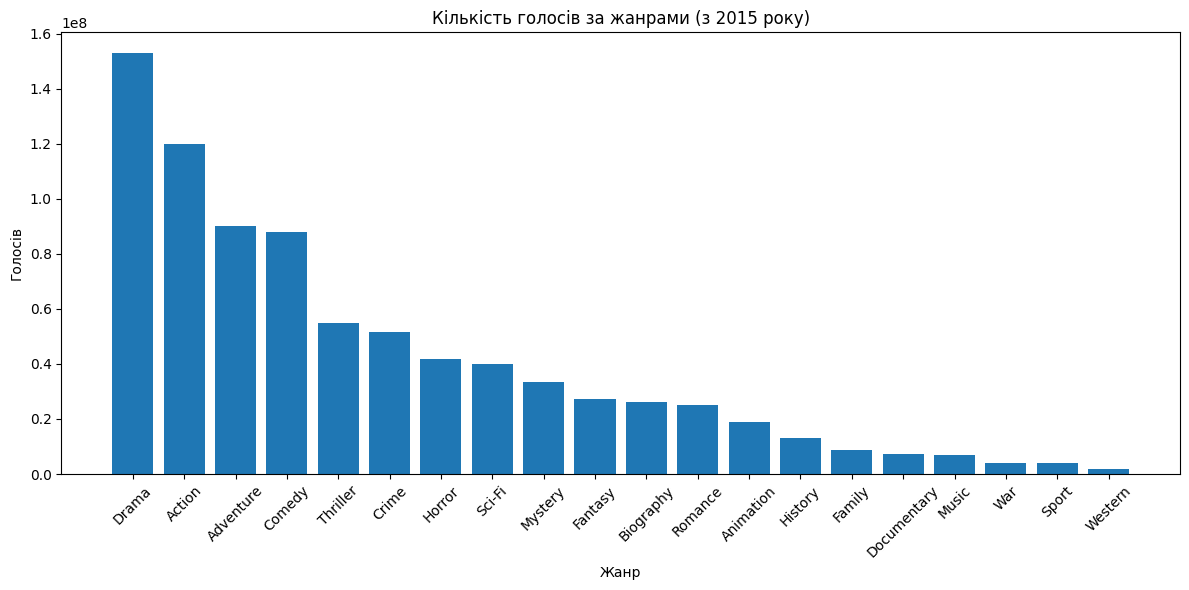

In [164]:
import matplotlib.pyplot as plt

df = genre_stats_total_votes.limit(20).toPandas()
plt.figure(figsize=(12,6))
plt.bar(df["genre"], df["total_votes"])
plt.xticks(rotation=45)
plt.title("Кількість голосів за жанрами (з 2015 року)")
plt.ylabel("Голосів")
plt.xlabel("Жанр")
plt.tight_layout()
plt.show()

In [78]:
print("Загальна кількість:", genre_stats_total_votes.count())

Total genres: 27


### Найуспішніші режисери фільмів а останні 5 років

In [184]:
director_stats = title_basics_df.join(
    title_ratings_df, "tconst"
).join(
    title_crew_df, "tconst"
).filter(
    (col("startYear") >= 2020) & 
    (col("titleType") == "movie")
).select(
    "directors", "averageRating", "numVotes"
).withColumn(
    "director", explode(split(col("directors"), ","))
).groupBy("director").agg(
    avg("averageRating").alias("avg_rating"),
    sum("numVotes").alias("total_votes"),
    count("*").alias("movie_count")
).withColumn(
    "director_rank",
    dense_rank().over(Window.orderBy(col("total_votes").desc()))
).orderBy(
    col("total_votes").desc()
)

director_stats_named = director_stats.join(
    name_basics_df.select("nconst", "primaryName"),
    director_stats["director"] == name_basics_df["nconst"],
    "left"
).select(
    "primaryName", "avg_rating", "total_votes", "movie_count", "director_rank"
).orderBy(col("total_votes").desc())

director_stats_named.write.csv("../data/results/top_directors_last_5_years.csv", header=True, mode="overwrite",)

In [185]:
director_stats_named.show(20)

+------------------+------------------+-----------+-----------+-------------+
|       primaryName|        avg_rating|total_votes|movie_count|director_rank|
+------------------+------------------+-----------+-----------+-------------+
|  Denis Villeneuve|              8.25|    1573295|          2|            1|
| Christopher Nolan| 7.800000000000001|    1506337|          2|            2|
|        Shawn Levy| 7.133333333333333|    1194150|          3|            3|
|         Jon Watts|              7.35|    1026530|          2|            4|
|       Matt Reeves|               7.8|     866693|          1|            5|
|        James Gunn| 7.550000000000001|     855893|          2|            6|
|       Kemp Powers|              8.25|     854852|          2|            7|
|       Zack Snyder|6.1499999999999995|     843584|          4|            8|
|   Joseph Kosinski|              6.85|     838386|          2|            9|
|      Ridley Scott|             6.675|     760505|          4| 

In [186]:
director_stats_pd = director_stats_named.limit(20).toPandas()
director_stats_pd

,primaryName,avg_rating,total_votes,movie_count,director_rank
0,Denis Villeneuve,8.250000,1573295,2,1
1,Christopher Nolan,7.800000,1506337,2,2
2,Shawn Levy,7.133333,1194150,3,3
3,Jon Watts,7.350000,1026530,2,4
4,Matt Reeves,7.800000,866693,1,5
5,James Gunn,7.550000,855893,2,6
6,Kemp Powers,8.250000,854852,2,7
7,Zack Snyder,6.150000,843584,4,8
8,Joseph Kosinski,6.850000,838386,2,9
9,Ridley Scott,6.675000,760505,4,10


/var/folders/jb/stfdcxd507jgwygfhm33x4t40000gn/T/ipykernel_32881/1669673345.py:9: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from current font.
  plt.tight_layout()
/Users/danyloklym/PycharmProjects/SPARK-PROJECT /venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


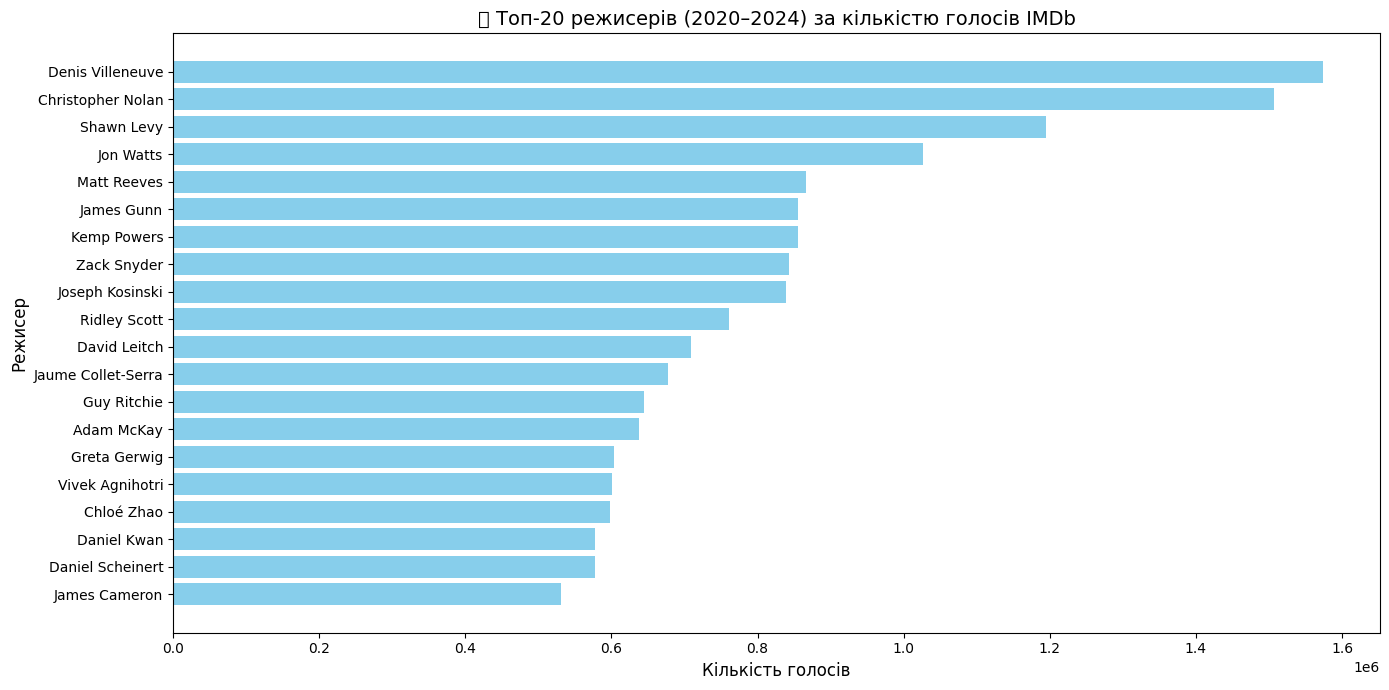

In [187]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.barh(director_stats_pd["primaryName"], director_stats_pd["total_votes"], color="skyblue")
plt.xlabel("Кількість голосів", fontsize=12)
plt.ylabel("Режисер", fontsize=12)
plt.title("Топ-20 режисерів (2020–2024) за кількістю голосів", fontsize=14)
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

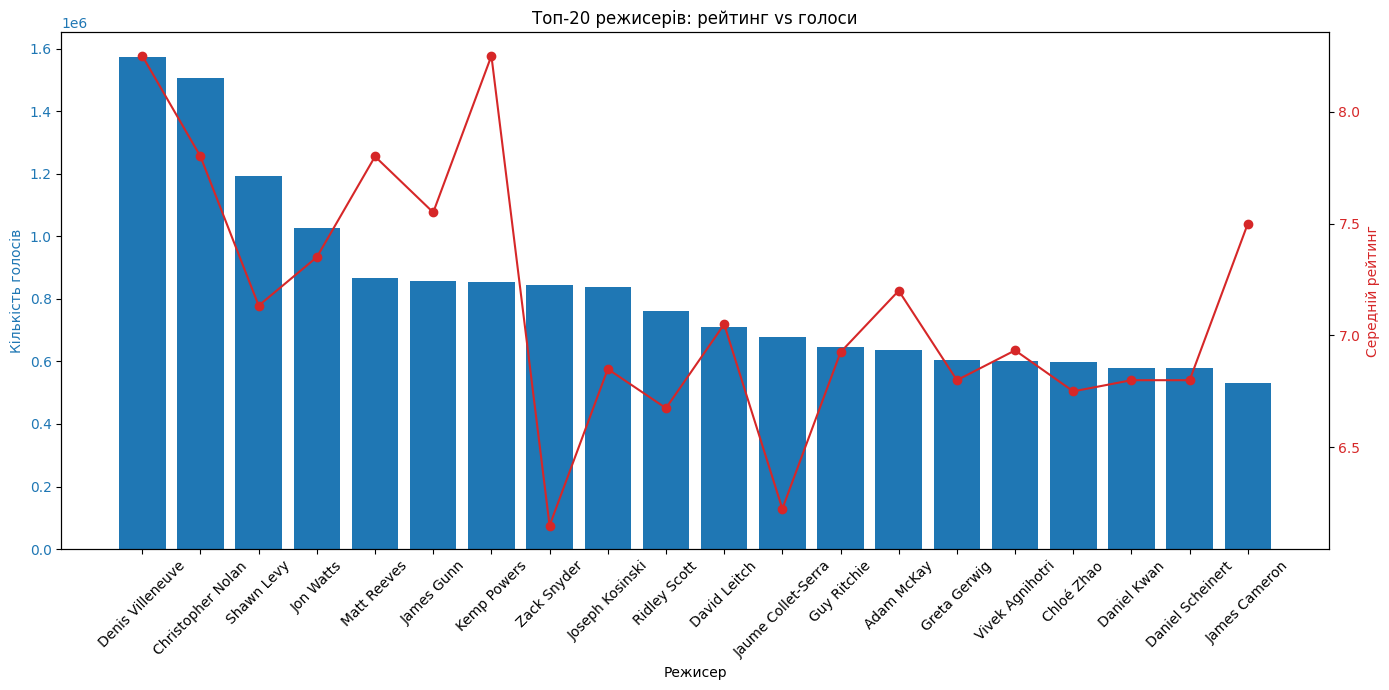

In [190]:
fig, ax1 = plt.subplots(figsize=(14, 7))

color = "tab:blue"
ax1.set_xlabel("Режисер")
ax1.set_ylabel("Кількість голосів", color=color)
ax1.bar(director_stats_pd["primaryName"], director_stats_pd["total_votes"], color=color)
ax1.tick_params(axis="y", labelcolor=color)
plt.xticks(rotation=45)

ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Середній рейтинг", color=color)
ax2.plot(director_stats_pd["primaryName"], director_stats_pd["avg_rating"], color=color, marker="o")
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Топ-20 режисерів: рейтинг vs голоси")
plt.tight_layout()
plt.show()

In [191]:
print("Загальна кількість:", director_stats.count())

Загальна кількість: 45203


### Проаналізувати, як тривалість фільму впливає на його рейтинг

In [193]:
duration_analysis = title_basics_df.join(
    title_ratings_df,
    "tconst"
).filter(
    (col("titleType") == "movie") &
    (col("runtimeMinutes").isNotNull())
).select(
    "runtimeMinutes",
    "averageRating",
    "numVotes"
).withColumn(
    "duration_category",
    when(col("runtimeMinutes") < 90, "Short")
    .when(col("runtimeMinutes") < 120, "Medium")
    .when(col("runtimeMinutes") < 150, "Long")
    .otherwise("Very Long")
).groupBy("duration_category").agg(
    avg("averageRating").alias("avg_rating"),
    avg("runtimeMinutes").alias("avg_duration"),
    count("*").alias("movie_count")
).orderBy(
    col("avg_rating").desc()
)

duration_analysis.write.csv("../data/results/movie_duration_analysis.csv", header=True, mode="overwrite",)

In [195]:
duration_analysis_pd = duration_analysis.limit(20).toPandas()
duration_analysis_pd

,duration_category,avg_rating,avg_duration,movie_count
0,Very Long,6.696842,201.073329,8455
1,Long,6.483296,130.882799,25341
2,Short,6.134605,68.287267,161780
3,Medium,6.082483,99.433584,133981


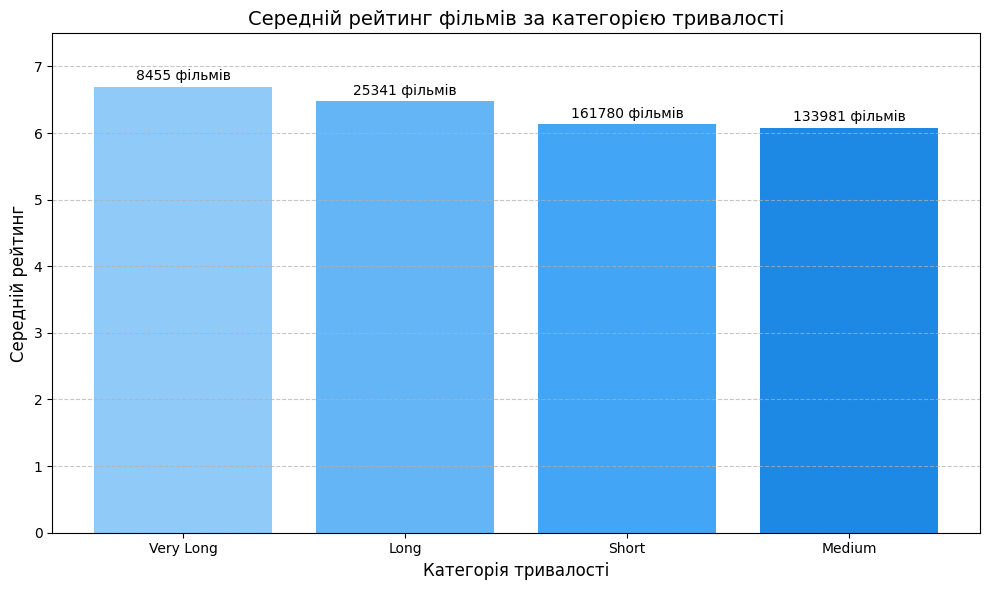

In [201]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bars = plt.bar(
    duration_analysis_pd["duration_category"],
    duration_analysis_pd["avg_rating"],
    color=["#90caf9", "#64b5f6", "#42a5f5", "#1e88e5"]
)

for bar, count_ in zip(bars, duration_analysis_pd["movie_count"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f"{count_} фільмів",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Середній рейтинг фільмів за категорією тривалості", fontsize=14)
plt.xlabel("Категорія тривалості", fontsize=12)
plt.ylabel("Середній рейтинг", fontsize=12)
plt.ylim(0, duration_analysis_pd["avg_rating"].max() + 0.8)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [194]:
print("Загальна кількість:", duration_analysis.count())

Загальна кількість: 4


### Знайти найактивніших акторів, та прослідкувати рейтинг їх фільмів

In [212]:
actor_stats = (
    title_principals_df.join(
        title_basics_df, "tconst"
    ).join(
        title_ratings_df, "tconst"
    ).join(
        name_basics_df, title_principals_df.nconst == name_basics_df.nconst
    )
    .filter(
        (col("category") == "actor") &
        (col("titleType") == "movie")
    )
    .select(
        title_principals_df.nconst.alias("actor_nconst"),
        name_basics_df.primaryName,
        "averageRating",
        "numVotes"
    )
    .groupBy(
        "actor_nconst",
        "primaryName"
    )
    .agg(
        count("*").alias("movie_count"),
        avg("averageRating").alias("avg_rating"),
        sum("numVotes").alias("total_votes")
    )
)

window_spec = Window.orderBy(col("movie_count").desc())
actor_stats = actor_stats.withColumn(
    "actor_rank",
    dense_rank().over(window_spec)
).orderBy(
    col("movie_count").desc()
)

actor_stats.write.csv("../data/results/top_actors_by_movie_count.csv", header=True, mode="overwrite")

In [209]:
actor_stats_pd = actor_stats.limit(20).toPandas()
actor_stats_pd

,actor_nconst,primaryName,movie_count,avg_rating,total_votes,actor_rank
0,nm0103977,Brahmanandam,815,5.953620,591876,1
1,nm0415549,Jagathy Sreekumar,536,5.565485,161934,2
2,nm0007106,Shakti Kapoor,487,5.220739,395141,3
3,nm0007123,Mammootty,419,6.400477,373311,4
4,nm0000616,Eric Roberts,388,4.667268,1197678,5
5,nm0621937,Nassar,383,6.115666,1324981,6
6,nm0482320,Mohanlal,380,6.327105,592511,7
7,nm0149822,Mithun Chakraborty,377,5.757825,948692,8
8,nm0080238,Tanikella Bharani,376,6.111968,469915,9
9,nm0451600,Anupam Kher,370,5.469730,3267700,10


In [213]:
print("Загальна кількість:", actor_stats.count())

Загальна кількість: 528629


### Проаналізувати популярність жанрів у різних регіонах

In [210]:
genre_region_analysis = title_akas_df.join(
    title_basics_df,
    title_akas_df.titleId == title_basics_df.tconst
).join(
    title_ratings_df,
    "tconst"
).filter(
    col("titleType") == "movie"
).select(
    "region",
    "genres",
    "averageRating",
    "numVotes"
).withColumn(
    "genre",
    explode(split(col("genres"), ","))
).groupBy(
    "region",
    "genre"
).agg(
    count("*").alias("movie_count"),
    avg("averageRating").alias("avg_rating"),
    sum("numVotes").alias("total_votes")
).withColumn(
    "genre_rank",
    dense_rank().over(Window.partitionBy("region").orderBy(col("total_votes").desc()))
).filter(
    col("genre_rank") <= 5
).orderBy(
    "region",
    col("total_votes").desc()
)

genre_region_analysis.write.csv("../data/results/genre_popularity_by_region.csv", header=True, mode="overwrite",)

In [217]:
genre_region_analysis_pd = genre_region_analysis.limit(20).toPandas()
genre_region_analysis_pd

,region,genre,movie_count,avg_rating,total_votes,genre_rank
0,AD,Drama,2,5.400000,310,1
1,AD,Crime,1,4.700000,298,2
2,AD,Mystery,1,4.700000,298,2
3,AD,Documentary,2,8.250000,29,3
4,AD,War,1,9.500000,14,4
5,AE,Drama,4880,6.290758,321135595,1
6,AE,Action,1863,6.019109,196404035,2
7,AE,Adventure,952,6.240756,160183258,3
8,AE,Comedy,2292,6.059293,151755834,4
9,AE,Crime,1405,6.363345,131968735,5


In [215]:
print("Загальна кількість:", genre_region_analysis.count())

Загальна кількість: 1045


### Проаналізувати тривалість та успішність телесеріалів

In [ ]:
tv_series_analysis = title_basics_df.join(
    title_ratings_df,
    "tconst"
).filter(
    (col("titleType") == "tvSeries") &
    (col("endYear").isNotNull())
).select(
    "primaryTitle",
    "startYear",
    "endYear",
    "averageRating",
    "numVotes"
).withColumn(
    "years_on_air",
    col("endYear") - col("startYear")
).groupBy("years_on_air").agg(
    count("*").alias("series_count"),
    avg("averageRating").alias("avg_rating"),
    avg("numVotes").alias("avg_votes")
).orderBy(
    col("years_on_air").desc()
)

tv_series_analysis.write.csv("../data/results/tv_series_duration_analysis.csv", header=True, mode="overwrite",)

In [216]:
tv_series_analysis_pd = tv_series_analysis.limit(20).toPandas()
tv_series_analysis_pd

,years_on_air,series_count,avg_rating,avg_votes
0,0,20434,6.687712,668.034893
1,1,11941,6.837057,1021.083661
2,2,5122,6.907673,2683.559352
3,3,3039,6.933432,4245.824284
4,4,1985,6.949219,5572.460453
5,5,1411,7.027498,9033.222537
6,6,961,6.990010,9981.174818
7,7,708,6.894350,14603.002825
8,8,551,6.933394,15796.987296
9,9,456,6.856360,14057.857456


In [214]:
print("Загальна кількість:", tv_series_analysis.count())

Загальна кількість: 68
